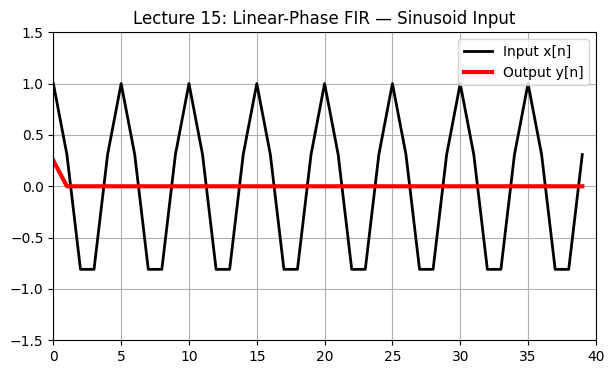

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 15: Linear-Phase FIR on a Sinusoid
# -----------------------------

# Time index
N = 40
n = np.arange(N)

# Input: single sinusoid (eigenfunction)
omega = 0.4 * np.pi
x = np.cos(omega * n)

# Symmetric FIR filter (linear phase)
b = np.array([0.25, 0.5, 0.25])
M = len(b)

# FIR filtering
y = np.zeros(N)
for i in range(N):
    for k in range(M):
        if i - k >= 0:
            y[i] += b[k] * x[i - k]

# Plot setup
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(0, N)
ax.set_ylim(-1.5, 1.5)
ax.grid(True)
ax.set_title("Lecture 15: Linear-Phase FIR — Sinusoid Input")

# Input signal (static)
ax.plot(n, x, 'k', lw=2, label="Input x[n]")

# Animated output signal
y_line, = ax.plot([], [], 'r', lw=3, label="Output y[n]")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture 9 style)
# -----------------------------
def update(frame):
    y_display = np.zeros(N)
    y_display[:frame+1] = y[:frame+1]

    y_line.set_data(n, y_display)
    return (y_line,)

anim = FuncAnimation(fig, update, frames=N, interval=200)

HTML(anim.to_jshtml())

The input pulse shape is unchanged in the output
The output appears later in time
There is no shape distortion